# 03 — Baseline Backtests
Short puts and iron condors from YAML configs, unconditioned vs
signal-conditioned (VIX rank / RSI). Every run lands in the results store.

### Baseline: unconditioned short puts
No filter—every date is a candidate entry. Control for comparison.


In [1]:
import sys
sys.path.insert(0, "../src")
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (11, 4)
pd.set_option("display.width", 160)

### Conditioned variants
vix_rank > 0.5 (above median), > 0.8 (top 20%), rsi14 < 40. Equity curve overlay.


f:\workspace\sophie-option-research\.venv\Lib\site-packages\empyrical\stats.py:1424: RuntimeWarning: divide by zero encountered in scalar divide
  return np.abs(np.percentile(returns, 95)) / np.abs(np.percentile(returns, 5))


{'total_trades': 275,
 'winning_trades': 237,
 'losing_trades': 38,
 'win_rate': 0.862,
 'total_pnl': 131799.5,
 'total_return': 1.318,
 'avg_pnl': 479.271,
 'avg_win': 1937.241,
 'avg_loss': -8613.855,
 'max_win': 7659.5,
 'max_loss': -22669.5,
 'profit_factor': 1.403,
 'max_drawdown': -0.403,
 'avg_days_in_trade': 10.604,
 'sharpe_ratio': 0.593,
 'sortino_ratio': 0.692,
 'var_95': -2.688,
 'cvar_95': -3.274,
 'calmar_ratio': 0.187,
 'omega_ratio': 1.449,
 'tail_ratio': 0.0}

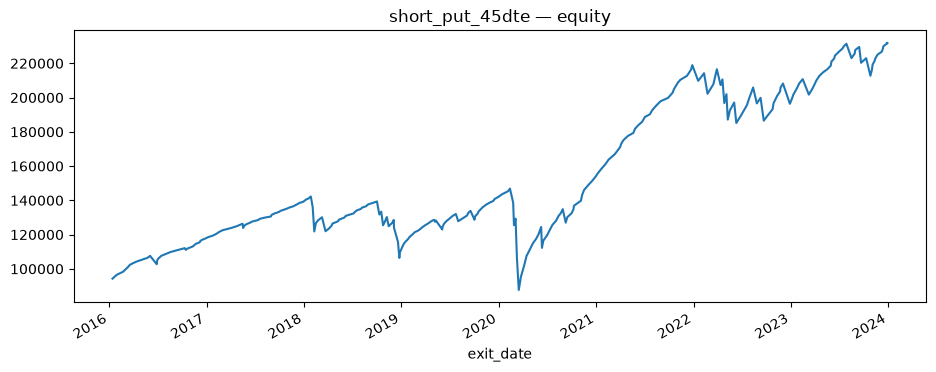

In [2]:
from lab.backtest import StrategyConfig, run_backtest
from lab.experiments import save_run
from lab.report import compare_runs, regime_breakdown

START, END = "2016-01-01", "2023-12-31"   # widen to 2010 for the full study

base = StrategyConfig.from_yaml("../configs/short_put_45dte.yaml").replace(start=START, end=END)
base_run = run_backtest(base)
save_run(base_run, tag="baseline")
base_run.equity_curve.plot(title=f"{base.name} — equity")
{k: round(v, 3) for k, v in base_run.metrics.items()}

## Conditioned entries: only sell puts when vol is elevated / oversold

### Results ranking
Sort by Sharpe. In-sample only—chapter 05 is honest test.


f:\workspace\sophie-option-research\.venv\Lib\site-packages\empyrical\stats.py:1424: RuntimeWarning: invalid value encountered in scalar divide
  return np.abs(np.percentile(returns, 95)) / np.abs(np.percentile(returns, 5))
f:\workspace\sophie-option-research\.venv\Lib\site-packages\empyrical\stats.py:1424: RuntimeWarning: invalid value encountered in scalar divide
  return np.abs(np.percentile(returns, 95)) / np.abs(np.percentile(returns, 5))
f:\workspace\sophie-option-research\.venv\Lib\site-packages\empyrical\stats.py:1424: RuntimeWarning: invalid value encountered in scalar divide
  return np.abs(np.percentile(returns, 95)) / np.abs(np.percentile(returns, 5))


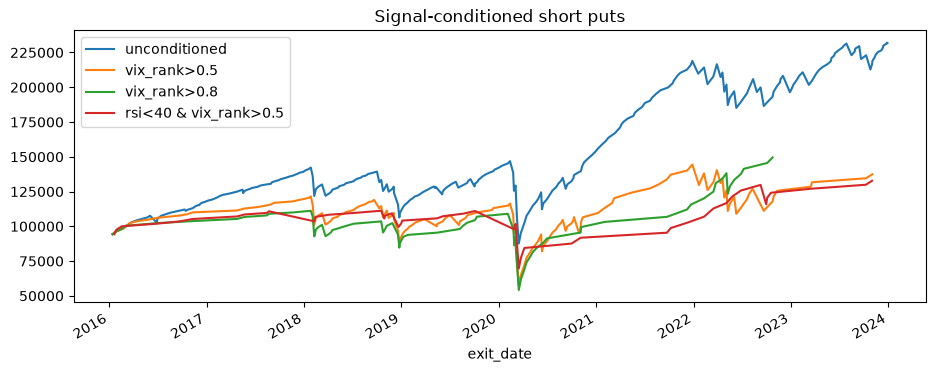

In [3]:
variants = {
    "vix_rank>0.5":            "vix_rank > 0.5",
    "vix_rank>0.8":            "vix_rank > 0.8",
    "rsi<40 & vix_rank>0.5":   "vix_rank > 0.5 and rsi14 < 40",
}
runs = {"unconditioned": base_run}
for label, expr in variants.items():
    cfg = base.replace(name=f"short_put|{label}", entry_filter=expr)
    runs[label] = run_backtest(cfg)
    save_run(runs[label], tag="baseline")

ax = None
for label, r in runs.items():
    ax = r.equity_curve.plot(ax=ax, label=label)
ax.legend(); ax.set_title("Signal-conditioned short puts");

### Iron condor baseline
Four-leg spread: 2 shorts + 2 wings. Premium collection + signal filtering.


In [4]:
compare_runs(tag="baseline").round(3)

,name,config_hash,entry_filter,total_trades,win_rate,total_return,sharpe_ratio,sortino_ratio,max_drawdown,profit_factor,calmar_ratio
0,short_put|vix_rank>0.8,f09bfca0f80a,vix_rank > 0.8,13,0.923,0.339,1.676,2.414,-0.121,3.283,2.490
1,iron_condor_45dte,56d68d692da4,vix_rank > 0.3,29,0.828,0.179,1.305,1.952,-0.046,2.633,1.376
2,short_put|rsi<40 & vix_rank>0.5,b339c0819498,vix_rank > 0.5 and rsi14 < 40,12,0.917,0.303,1.060,1.582,-0.109,3.175,0.985
3,short_put_45dte,53ebc2077897,,275,0.862,1.318,0.593,0.692,-0.403,1.403,0.187
4,short_put|vix_rank>0.8,d4c3ffbb9ecf,vix_rank > 0.8,76,0.829,0.495,0.334,0.405,-0.512,1.372,0.081
5,short_put_45dte,e5e444b32ef6,,71,0.803,0.115,0.288,0.336,-0.326,1.079,0.110
6,short_put|rsi<40 & vix_rank>0.5,106132c852b3,vix_rank > 0.5 and rsi14 < 40,49,0.837,0.327,0.275,0.335,-0.374,1.375,0.068
7,short_put|vix_rank>0.5,a5d0249f812d,vix_rank > 0.5,156,0.827,0.374,0.250,0.292,-0.528,1.136,0.054
8,short_put|vix_rank>0.5,a82fbc007678,vix_rank > 0.5,30,0.767,-0.071,0.062,0.072,-0.327,0.924,-0.077


## Iron condor baseline

### Regime breakdown
Performance by VIX-rank quartile: high vol vs low vol returns.


f:\workspace\sophie-option-research\.venv\Lib\site-packages\empyrical\stats.py:1424: RuntimeWarning: invalid value encountered in scalar divide
  return np.abs(np.percentile(returns, 95)) / np.abs(np.percentile(returns, 5))


{'total_trades': 136,
 'winning_trades': 106,
 'losing_trades': 30,
 'win_rate': 0.779,
 'total_pnl': 40642.5,
 'total_return': 0.406,
 'avg_pnl': 298.842,
 'avg_win': 704.491,
 'avg_loss': -1134.45,
 'max_win': 2540.0,
 'max_loss': -5655.0,
 'profit_factor': 2.194,
 'max_drawdown': -0.087,
 'avg_days_in_trade': 16.287,
 'sharpe_ratio': 0.893,
 'sortino_ratio': 1.163,
 'var_95': -1.058,
 'cvar_95': -3.085,
 'calmar_ratio': 0.349,
 'omega_ratio': 2.187,
 'tail_ratio': 0.0}

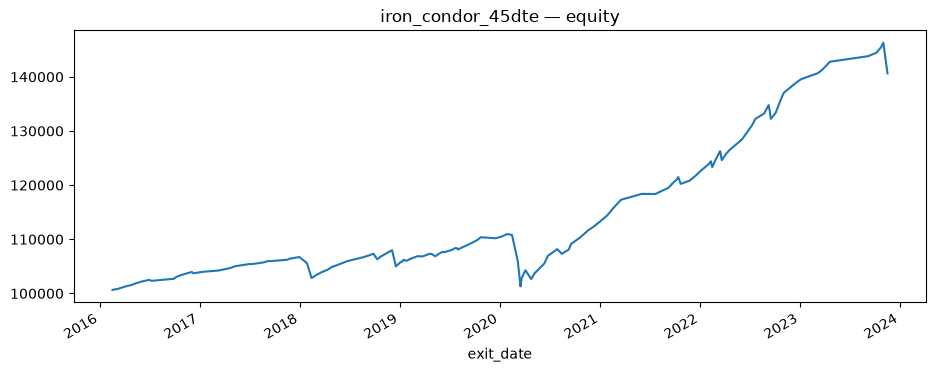

In [5]:
ic = StrategyConfig.from_yaml("../configs/iron_condor_45dte.yaml").replace(start=START, end=END)
ic_run = run_backtest(ic)
save_run(ic_run, tag="baseline")
ic_run.equity_curve.plot(title=f"{ic.name} — equity")
{k: round(v, 3) for k, v in ic_run.metrics.items()}

## Where does the P&L come from? Performance by VIX-rank regime

In [6]:
regime_breakdown(base_run.trade_log, feature="vix_rank", bins=4).round(3)

,trades,win_rate,avg_realized_pnl,total_realized_pnl
bucket,,,,
"(0.0029699999999999996, 0.0714]",70,0.900,621.393,43497.5
"(0.0714, 0.349]",68,0.912,1032.596,70216.5
"(0.349, 0.706]",68,0.838,151.235,10284.0
"(0.706, 1.0]",69,0.797,113.065,7801.5
